In [6]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import about, basis, destroy, mcsolve, mesolve, sigmam, sigmax
import pandas as pd
import lmfit
import corner
import emcee
from pylab import *
ion()

In [7]:
##SET up fitting function
def exponential_numerical_3p(t_s,A,C,T_1):
    return A*np.exp(-t_s/T_1) + C

#SET UP DATA
gamma_relax=5.0
T_1= 1/gamma_relax
n_samp=1000

In [8]:
#Generate 3 points to determine B
x0, x1, x2 = .1, .2, .3


#Numerically solve to find B
from scipy.optimize import fsolve

def Eq_for_B(x, x0, x1, x2): #Equation that solves for B (in this case x=B)
    #Assume A1, C=0, and known T1
    y0, y1, y2 = exponential_numerical_3p(x0,1,0,T_1), exponential_numerical_3p(x1,1,0,T_1), exponential_numerical_3p(x2,1,0,T_1)
    term1=(np.exp(-x*x0)-np.exp(-x*x1))/(np.exp(-x*x1)-np.exp(-x*x2))
    term2=(y0-y1)/(y1-y2)
    return term1 - term2

In [9]:
import sympy as sp
from sympy.abc import x, y, z, gamma
from sympy import lambdify
from sympy.solvers import solve
from sympy.plotting import plot

In [10]:
# Define symbols
y0, y1, y2, B, x0, x1, x2 = sp.symbols('y0 y1 y2 B x0 x1 x2')

# Define B as a function of y0, y1, and y2
B_func = sp.Function('B')(y0, y1, y2)

# Define the equation
eq = ((y0 - y1) / (y1 - y2)) - (sp.exp(-B_func * x0) - sp.exp(-B_func * x1)) / (sp.exp(-B_func * x1) - sp.exp(-B_func * x2))


# Differentiate equation with respect to y0, y1, and y2
d_eq_dy0 = sp.simplify(sp.diff(eq, y0))
d_eq_dy1 = sp.simplify(sp.diff(eq, y1))
d_eq_dy2 = sp.simplify(sp.diff(eq, y2))

#Solve equation to isolate derivatives
db0=sp.simplify(sp.solve(d_eq_dy0,sp.diff(B_func, y0))[0])
db1=sp.simplify(sp.solve(d_eq_dy1,sp.diff(B_func, y1))[0])
db2=sp.simplify(sp.solve(d_eq_dy2,sp.diff(B_func, y2))[0])

#Define shot noises
T,t, N = sp.symbols('T t N')
N = T/(x0+x1+x2+3*t)
sigma_y0 = sp.simplify(sp.sqrt((y0-y0*y0)/N))
sigma_y1 = sp.simplify(sp.sqrt((y1-y1*y1)/N))
sigma_y2 = sp.simplify(sp.sqrt((y2-y2*y2)/N))

#Define new equation
f= sp.sqrt(db0**2 * sigma_y0**2 + db1**2 * sigma_y1**2 + db2**2 * sigma_y2**2)


In [11]:

print_latex(db0)

NameError: name 'print_latex' is not defined

In [12]:
from sympy import Matrix, print_latex

print_latex(f)

\sqrt{- \frac{y_{0} \left(y_{0} - 1\right) \left(e^{x_{1} B{\left(y_{0},y_{1},y_{2} \right)}} - e^{x_{2} B{\left(y_{0},y_{1},y_{2} \right)}}\right)^{4} \cdot \left(3 t + x_{0} + x_{1} + x_{2}\right) e^{- 2 \left(- x_{0} + x_{1} + x_{2}\right) B{\left(y_{0},y_{1},y_{2} \right)}}}{T \left(x_{0} y_{1} e^{x_{1} B{\left(y_{0},y_{1},y_{2} \right)}} - x_{0} y_{1} e^{x_{2} B{\left(y_{0},y_{1},y_{2} \right)}} - x_{0} y_{2} e^{x_{1} B{\left(y_{0},y_{1},y_{2} \right)}} + x_{0} y_{2} e^{x_{2} B{\left(y_{0},y_{1},y_{2} \right)}} - x_{1} y_{1} e^{x_{0} B{\left(y_{0},y_{1},y_{2} \right)}} + x_{1} y_{1} e^{x_{2} B{\left(y_{0},y_{1},y_{2} \right)}} + x_{1} y_{2} e^{x_{0} B{\left(y_{0},y_{1},y_{2} \right)}} - x_{1} y_{2} e^{x_{2} B{\left(y_{0},y_{1},y_{2} \right)}} + x_{2} y_{1} e^{x_{0} B{\left(y_{0},y_{1},y_{2} \right)}} - x_{2} y_{1} e^{x_{1} B{\left(y_{0},y_{1},y_{2} \right)}} - x_{2} y_{2} e^{x_{0} B{\left(y_{0},y_{1},y_{2} \right)}} + x_{2} y_{2} e^{x_{1} B{\left(y_{0},y_{1},y_{2} \right)}}\right)

In [13]:
sigma_y0

sqrt(-y0*(y0 - 1)*(3*t + x0 + x1 + x2)/T)

In [14]:
A, C = sp.symbols('A C')
expp= A*sp.exp(-B*x0) +C

In [15]:
f.subs(y0,expp)

sqrt(-y1*(y1 - 1)*(exp(x1*B(A*exp(-B*x0) + C, y1, y2)) - exp(x2*B(A*exp(-B*x0) + C, y1, y2)))**4*(-A*exp(-B*x0) - C + y2)**2*(3*t + x0 + x1 + x2)*exp(-2*(-x0 + x1 + x2)*B(A*exp(-B*x0) + C, y1, y2))/(T*(y1 - y2)**4*(x0*exp(x1*B(A*exp(-B*x0) + C, y1, y2)) - x0*exp(x2*B(A*exp(-B*x0) + C, y1, y2)) - x1*exp(x0*B(A*exp(-B*x0) + C, y1, y2)) + x1*exp(x2*B(A*exp(-B*x0) + C, y1, y2)) + x2*exp(x0*B(A*exp(-B*x0) + C, y1, y2)) - x2*exp(x1*B(A*exp(-B*x0) + C, y1, y2)))**2) - y2*(y2 - 1)*(exp(x1*B(A*exp(-B*x0) + C, y1, y2)) - exp(x2*B(A*exp(-B*x0) + C, y1, y2)))**4*(A*exp(-B*x0) + C - y1)**2*(3*t + x0 + x1 + x2)*exp(-2*(-x0 + x1 + x2)*B(A*exp(-B*x0) + C, y1, y2))/(T*(y1 - y2)**4*(x0*exp(x1*B(A*exp(-B*x0) + C, y1, y2)) - x0*exp(x2*B(A*exp(-B*x0) + C, y1, y2)) - x1*exp(x0*B(A*exp(-B*x0) + C, y1, y2)) + x1*exp(x2*B(A*exp(-B*x0) + C, y1, y2)) + x2*exp(x0*B(A*exp(-B*x0) + C, y1, y2)) - x2*exp(x1*B(A*exp(-B*x0) + C, y1, y2)))**2) - (A*exp(-B*x0) + C)*(exp(x1*B(A*exp(-B*x0) + C, y1, y2)) - exp(x2*B(A*exp(-B

In [16]:
sp.pprint(sp.printing.octave.octave_code(f))

                                                                              
                                                                              
sqrt(-y0.*(y0 - 1).*(exp(x1.*B(y0, y1, y2)) - exp(x2.*B(y0, y1, y2))).^4.*(3*t

                                                                              
                                                                              
 + x0 + x1 + x2).*exp(-2*(-x0 + x1 + x2).*B(y0, y1, y2))./(T.*(x0.*y1.*exp(x1.

                                                                              
                                                                              
*B(y0, y1, y2)) - x0.*y1.*exp(x2.*B(y0, y1, y2)) - x0.*y2.*exp(x1.*B(y0, y1, y

                                                                              
                                                                              
2)) + x0.*y2.*exp(x2.*B(y0, y1, y2)) - x1.*y1.*exp(x0.*B(y0, y1, y2)) + x1.*y1

                                                

In [18]:
import numpy as np
from scipy.optimize import differential_evolution

gamma_relax = 1.0
B = gamma_relax
T_1 = 1 / gamma_relax
t = 0.01
T = 100

# Define your objective function
def objective_function(x):
    x0, x1, x2 = x

    A = 1
    C = 0
    y0 = exponential_numerical_3p(x0, A, C, T_1)
    y1 = exponential_numerical_3p(x1, A, C, T_1)
    y2 = exponential_numerical_3p(x2, A, C, T_1)

    # Define function here sigma_B
    sigma_gamma = np.sqrt(
        -y0
        * (y0 - 1)
        * (np.exp(x1 * B) - np.exp(x2 * B)) ** 4
        * (3 * t + x0 + x1 + x2)
        * np.exp(-2 * (-x0 + x1 + x2) * B)
        / (
            T
            * (
                x0 * y1 * np.exp(x1 * B)
                - x0 * y1 * np.exp(x2 * B)
                - x0 * y2 * np.exp(x1 * B)
                + x0 * y2 * np.exp(x2 * B)
                - x1 * y1 * np.exp(x0 * B)
                + x1 * y1 * np.exp(x2 * B)
                + x1 * y2 * np.exp(x0 * B)
                - x1 * y2 * np.exp(x2 * B)
                + x2 * y1 * np.exp(x0 * B)
                - x2 * y1 * np.exp(x1 * B)
                - x2 * y2 * np.exp(x0 * B)
                + x2 * y2 * np.exp(x1 * B)
            )
            ** 2
        )
    ) - y1 * (-y0 + y2) ** 2 * (
        y1 - 1
    ) * (
        np.exp(x1 * B) - np.exp(x2 * B)
    ) ** 4 * (
        3 * t + x0 + x1 + x2
    ) * np.exp(
        -2 * (-x0 + x1 + x2) * B
    ) / (
        T
        * (
            y1 - y2
        )
        ** 4
        * (
            x0 * np.exp(x1 * B)
            - x0 * np.exp(x2 * B)
            - x1 * np.exp(x0 * B)
            + x1 * np.exp(x2 * B)
            + x2 * np.exp(x0 * B)
            - x2 * np.exp(x1 * B)
        )
        ** 2
    ) - y2 * (
        y0 - y1
    ) ** 2 * (
        y2 - 1
    ) * (
        np.exp(x1 * B) - np.exp(x2 * B)
    ) ** 4 * (
        3 * t + x0 + x1 + x2
    ) * np.exp(
        -2 * (-x0 + x1 + x2) * B
    ) / (
        T
        * (
            y1 - y2
        )
        ** 4
        * (
            x0 * np.exp(x1 * B)
            - x0 * np.exp(x2 * B)
            - x1 * np.exp(x0 * B)
            + x1 * np.exp(x2 * B)
            + x2 * np.exp(x0 * B)
            - x2 * np.exp(x1 * B)
        )
        ** 2
    )

    # Define conversion to t1
    return sigma_gamma / gamma_relax ** 2


# Minimize the function using Differential Evolution
result = differential_evolution(
    objective_function, bounds=[(0, 100), (0, 100), (0, 100)], tol=1e-6
)

# Print the result
print("Optimal values:", result.x)
print("Optimal function value:", result.fun)


Optimal values: [0.        4.5308475 1.0939674]
Optimal function value: 0.11566662670841996


/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_52952/4268327264.py:22: RuntimeWarning: invalid value encountered in scalar divide
  -y0
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_52952/4268327264.py:45: RuntimeWarning: invalid value encountered in scalar divide
  ) - y1 * (-y0 + y2) ** 2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_52952/4268327264.py:68: RuntimeWarning: invalid value encountered in scalar divide
  ) - y2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_52952/4268327264.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  -y0
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_52952/4268327264.py:68: RuntimeWarning: divide by zero encountered in scalar divide
  ) - y2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_52952/4268327264.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  ) - y1 * (-y0 + y2) ** 2 * (


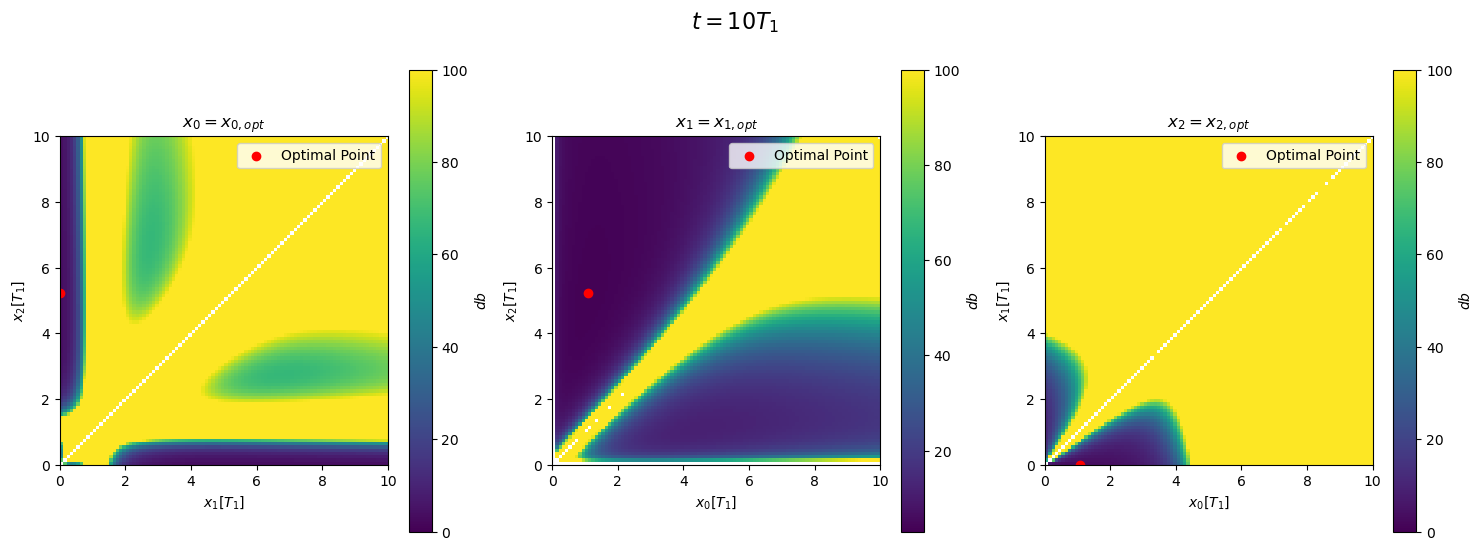

In [10]:


M=10
# Generate data for plotting
x_vals = np.linspace(0, M, 100)
X, Y = np.meshgrid(x_vals, x_vals)

# Fixing x0
Z_x0 = np.zeros_like(X)
for i in range(len(x_vals)):
    for j in range(len(x_vals)):
        Z_x0[i, j] = objective_function([result.x[0], X[i, j], Y[i, j]])

# Fixing x1
Z_x1 = np.zeros_like(X)
for i in range(len(x_vals)):
    for j in range(len(x_vals)):
        Z_x1[i, j] = objective_function([X[i, j], result.x[1], Y[i, j]])

# Fixing x2
Z_x2 = np.zeros_like(X)
for i in range(len(x_vals)):
    for j in range(len(x_vals)):
        Z_x2[i, j] = objective_function([X[i, j], Y[i, j], result.x[2]])

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

plot0= axs[0].imshow(Z_x0, extent=(0, M, 0, M), origin='lower', cmap='viridis', vmin=0, vmax=100)
axs[0].set_title('$x_0 = x_{0,opt}$')
axs[0].set_xlabel('$x_1 [T_1]$')
axs[0].set_ylabel('$x_2 [T_1]$')
axs[0].scatter([result.x[1]],[result.x[2]], color='red', label='Optimal Point')
axs[0].legend()
fig.colorbar(plot0,label='$db$')

plot1= axs[1].imshow(Z_x1, extent=(0, M, 0, M), origin='lower', cmap='viridis' ,vmin=3, vmax=100)
axs[1].set_title('$x_1 = x_{1,opt}$')
axs[1].set_xlabel('$x_0 [T_1]$')
axs[1].set_ylabel('$x_2 [T_1]$')
axs[1].scatter([result.x[0]],[result.x[2]], color='red', label='Optimal Point')
axs[1].legend()
fig.colorbar(plot1,label='$db$')

plot2 = axs[2].imshow(Z_x2, extent=(0, M, 0, M), origin='lower', cmap='viridis',vmin=0, vmax=100)
axs[2].set_title('$x_2 = x_{2,opt}$')
axs[2].set_xlabel('$x_0 [T_1]$')
axs[2].set_ylabel('$x_1 [T_1]$')
axs[2].scatter([result.x[0]],[result.x[1]], color='red', label='Optimal Point')
axs[2].legend()
fig.colorbar(plot2,label='$db$')
fig.suptitle('$t=10T_1$', fontsize=16)
plt.savefig("slices2.png", bbox_inches='tight', dpi=300)
plt.show()


/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:22: RuntimeWarning: invalid value encountered in scalar divide
  -y0
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:45: RuntimeWarning: invalid value encountered in scalar divide
  ) - y1 * (-y0 + y2) ** 2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:68: RuntimeWarning: invalid value encountered in scalar divide
  ) - y2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  -y0
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:68: RuntimeWarning: divide by zero encountered in scalar divide
  ) - y2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  ) - y1 * (-y0 + y2) ** 2 * (


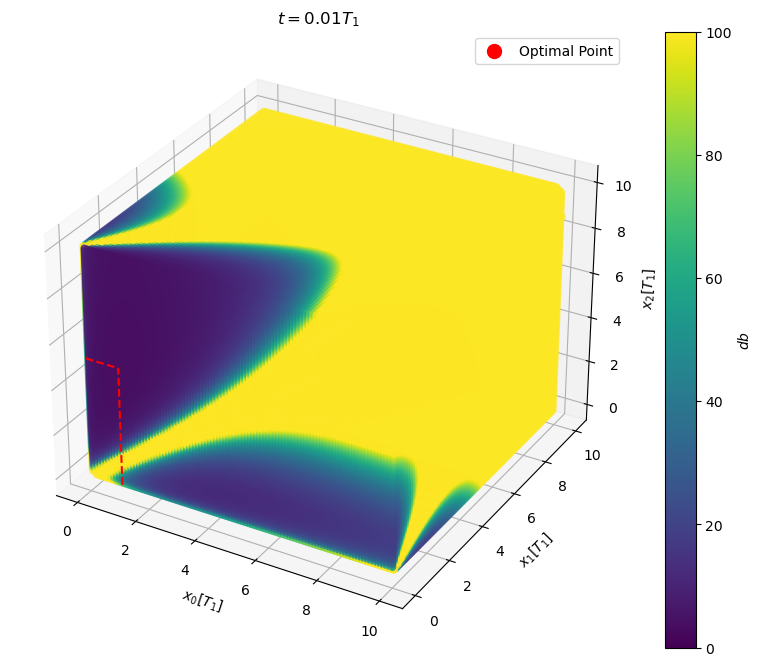

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import product, combinations


# Generate data for plotting
M = 10
x_vals = np.linspace(0, M, 100)
X, Y, Z = np.meshgrid(x_vals, x_vals, x_vals)

# Compute the objective function values
objective_values = np.zeros_like(X)
for i in range(len(x_vals)):
    for j in range(len(x_vals)):
        for k in range(len(x_vals)):
            objective_values[i, j, k] = objective_function([X[i, j, k], Y[i, j, k], Z[i, j, k]])

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a 3D scatter plot
scat = ax.scatter(X, Y, Z, c=objective_values.flatten(), cmap='viridis',vmin=0, vmax=100, zorder=1)
fig.colorbar(scat, ax=ax, label='$db$')

ax.set_title('$t=0.01T_1$')
ax.set_xlabel('$x_0 [T_1]$')
ax.set_ylabel('$x_1 [T_1]$')
ax.set_zlabel('$x_2 [T_1]$')

ax.scatter(result.x[0], result.x[1], result.x[2], color='red', s=100, zorder=3, label='Optimal Point')
# Plot dashed red lines from each axis to the point
ax.plot([result.x[0], result.x[0]], [result.x[1], result.x[1]], [0, result.x[2]], 'r--', zorder=5)
ax.plot([result.x[0], result.x[0]], [0, result.x[1]], [result.x[2], result.x[2]], 'r--', zorder=5)
ax.plot([0, result.x[0]], [result.x[1], result.x[1]], [result.x[2], result.x[2]], 'r--', zorder=5)


plt.legend()
plt.savefig("cube0.01.pdf", bbox_inches='tight', dpi=100)
plt.show()



/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:22: RuntimeWarning: invalid value encountered in scalar divide
  -y0
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:45: RuntimeWarning: invalid value encountered in scalar divide
  ) - y1 * (-y0 + y2) ** 2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:68: RuntimeWarning: invalid value encountered in scalar divide
  ) - y2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  -y0
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:68: RuntimeWarning: divide by zero encountered in scalar divide
  ) - y2 * (
/var/folders/vd/k7vp25tj2352pk9kk8r2__k00000gn/T/ipykernel_29491/4268327264.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  ) - y1 * (-y0 + y2) ** 2 * (
Generating Video: 73it [03:15,  2.67s/it]    

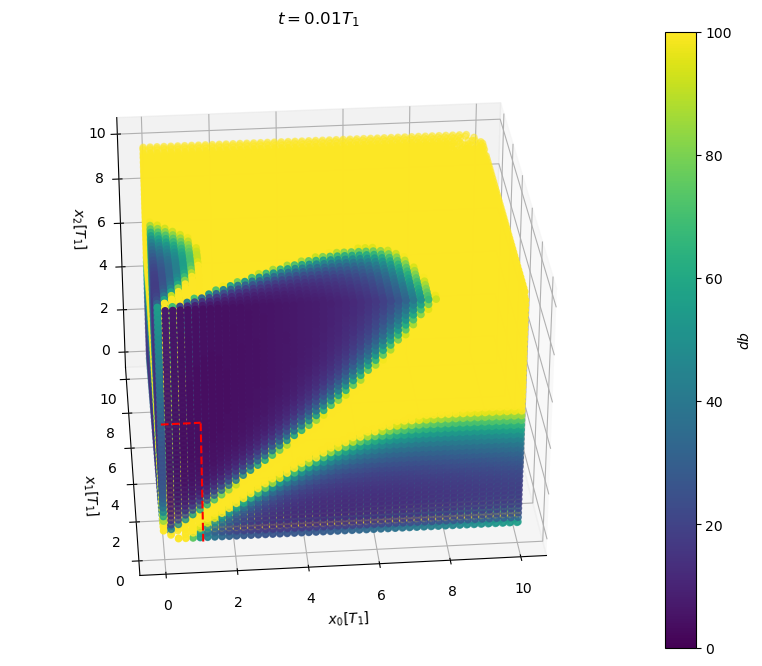

In [30]:
#####ROTATING VIDEO

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from tqdm import tqdm


# Generate data for plotting
M = 10
x_vals = np.linspace(0, M, 50)  # Reduced number of points
X, Y, Z = np.meshgrid(x_vals, x_vals, x_vals)

# Compute the objective function values
objective_values = np.zeros_like(X)
for i in range(len(x_vals)):
    for j in range(len(x_vals)):
        for k in range(len(x_vals)):
            objective_values[i, j, k] = objective_function([X[i, j, k], Y[i, j, k], Z[i, j, k]])

# Result placeholder (replace with actual optimization result)
result = result.x

# Initialize the figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Initial plot setup
scat = ax.scatter(X, Y, Z, c=objective_values.flatten(), cmap='viridis', vmin=0, vmax=100, zorder=1)
ax.scatter(result[0], result[1], result[2], color='red', s=100, zorder=3, label='Optimal Point')
ax.plot([result[0], result[0]], [result[1], result[1]], [0, result[2]], 'r--', zorder=5)
ax.plot([result[0], result[0]], [0, result[1]], [result[2], result[2]], 'r--', zorder=5)
ax.plot([0, result[0]], [result[1], result[1]], [result[2], result[2]], 'r--', zorder=5)

ax.set_title('$t=0.01 T_1$')
ax.set_xlabel('$x_0 [T_1]$')
ax.set_ylabel('$x_1 [T_1]$')
ax.set_zlabel('$x_2 [T_1]$')

fig.colorbar(scat, ax=ax, label='$db$')

# Define the number of frames and create a progress bar
frames = np.arange(-90, 270, 5)
progress_bar = tqdm(total=len(frames), desc="Generating Video")

# Update function for animation
def update(frame):
    ax.view_init(elev=30, azim=frame)
    progress_bar.update(1)

# Create the animation
ani = FuncAnimation(fig, update, frames=frames, interval=100)

# Save the animation as a video file
ani.save('rotation0.01T.mp4', writer='ffmpeg', dpi=100)

# Close the progress bar
progress_bar.close()

plt.show()


In [ ]:
#########case with t=10T1

In [10]:
import numpy as np
import scipy
import scipy.optimize
import sympy as sp

t_reset = 0

y = sp.Array(sp.symbols("y:3"))
x = sp.Array(sp.symbols("x:3"))
b = sp.Function("b")(y[0], y[1], y[2])


eq = (sp.exp(-x[0] * b) - sp.exp(-x[1] * b)) / (
    sp.exp(-x[1] * b) - sp.exp(-x[2] * b)
) - (y[0] - y[1]) / (y[1] - y[2])

deriv = sp.diff(eq, y[0])


db_dy0 = sp.simplify(
    sp.solve(
        sp.diff(
            eq,
            y[0],
        ),
        sp.diff(b, y[0]),
    )[0]
)


db_dy0_in_x = sp.simplify(
    db_dy0.subs([(b, 1)] + list((y[i], sp.exp(-x[i])) for i in range(3)))
)

xp = sp.Array(sp.symbols("xp:3"))
db_dy_in_x = [0, 0, 0]

db_dy_in_x[0] = db_dy0_in_x
db_dy_in_x[1] = db_dy0_in_x.subs([(x[2], xp[0]), (x[1], xp[2]), (x[0], xp[1])]).subs(
    [(xp[0], x[0]), (xp[1], x[1]), (xp[2], x[2])]
)
db_dy_in_x[2] = db_dy0_in_x.subs([(x[2], xp[1]), (x[1], xp[0]), (x[0], xp[2])]).subs(
    [(xp[0], x[0]), (xp[1], x[1]), (xp[2], x[2])]
)


dy = [(sp.exp(-x[i]) - sp.exp(-2 * x[i])) * (sum(x) + 3 * t_reset) for i in range(3)]
result = sp.sqrt(sum(db_dy_in_x[i] ** 2 * dy[i] for i in range(3)))

def db(x_values):

    result = sp.sqrt(sum(db_dy_in_x[i] ** 2 * dy[i] for i in range(3))).evalf(
        subs={x[i]: x_values[i] for i in range(3)}
    )
    # print(x_values, result)

    return result


res= scipy.optimize.minimize(db, [1, 10, 50], bounds=[(0, 100), (0.01, 100), (0.02, 100)])
res.x

array([0.        , 1.09121892, 4.5193565 ])

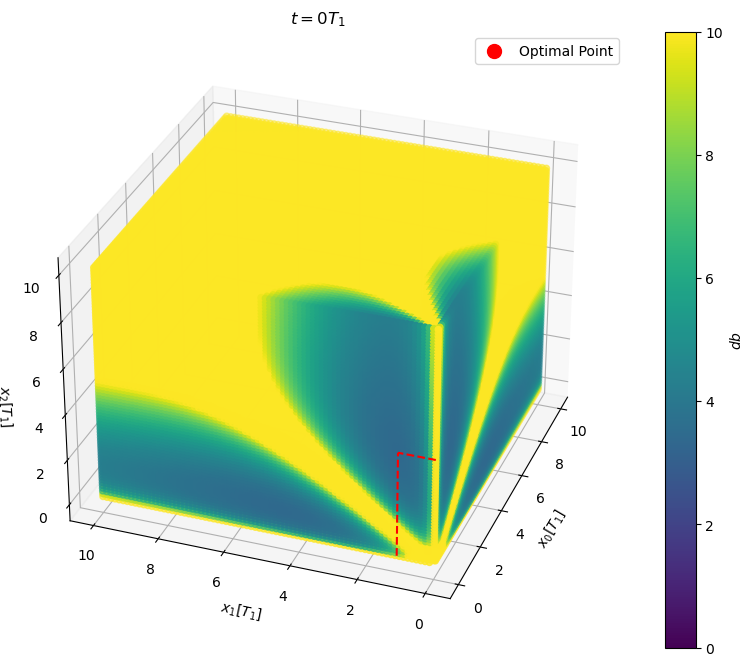

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import product, combinations
result=res

# Generate data for plotting
M = 10
x_vals = np.linspace(0, M,80)
X, Y, Z = np.meshgrid(x_vals, x_vals, x_vals)

# Compute the objective function values
objective_values = np.zeros_like(X)
for i in range(len(x_vals)):
    for j in range(len(x_vals)):
        for k in range(len(x_vals)):
            objective_values[i, j, k] = db([X[i, j, k], Y[i, j, k], Z[i, j, k]])

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a 3D scatter plot
scat = ax.scatter(X, Y, Z, c=objective_values.flatten(), cmap='viridis',vmin=0, vmax=10, zorder=1)
fig.colorbar(scat, ax=ax, label='$db$')

ax.set_title('$t=0 T_1$')
ax.set_xlabel('$x_0 [T_1]$')
ax.set_ylabel('$x_1 [T_1]$')
ax.set_zlabel('$x_2 [T_1]$')

ax.scatter(result.x[0], result.x[1], result.x[2], color='red', s=100, zorder=3, label='Optimal Point')
# Plot dashed red lines from each axis to the point
ax.plot([result.x[0], result.x[0]], [result.x[1], result.x[1]], [0, result.x[2]], 'r--', zorder=5)
ax.plot([result.x[0], result.x[0]], [0, result.x[1]], [result.x[2], result.x[2]], 'r--', zorder=5)
ax.plot([0, result.x[0]], [result.x[1], result.x[1]], [result.x[2], result.x[2]], 'r--', zorder=5)

ax.view_init(elev=30, azim=200)  # Adjust the elevation and azimuth as needed

plt.legend()
plt.savefig("everything0pt2.pdf", bbox_inches='tight', dpi=100)
plt.show()